In [12]:
from IPython.display import Image, display
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt
import os


In [13]:
#import os
#os.chdir("/thkim0/github/AIFFEL_quest_rs/Exploration/Ex01")
#os.getcwd()

In [14]:
from pathlib import Path

def find_project_root():

    cwd = Path.cwd()
    # 1. 현재 위치가 프로젝트 루트인 경우
    if (cwd / "images").exists():
        return cwd
    # 2. 현재 위치의 하위 폴더 중 images 폴더가 있는 곳 탐색
    for path in cwd.rglob("images"):
        if path.is_dir():
            return path.parent

    raise FileNotFoundError("file not found")


PROJECT_ROOT = find_project_root()
IMAGE_DIR = PROJECT_ROOT / "images"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("IMAGE_DIR:", IMAGE_DIR)


# 모델 로드
model = deeplabv3_resnet101(pretrained=True).eval()

# 모델 입력 전처리
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),
    T.ToTensor(),
])


def blur_background(img_path, out_path, blur_ksize=(256, 256)):
    img_path = Path(img_path)
    out_path = Path(out_path)

    # 이미지 읽기
    img_orig = cv2.imread(str(img_path))

    if img_orig is None:
        raise FileNotFoundError(
            f"이미지를 읽을 수 없습니다: {img_path}\n"
            f"현재 작업 경로: {Path.cwd()}\n"
            f"images 폴더 안 파일들: {[p.name for p in IMAGE_DIR.iterdir()]}"
        )

    # BGR -> RGB
    img_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

    # 추론 입력
    input_tensor = transform(img_rgb).unsqueeze(0)

    # 세그멘테이션 추론
    with torch.no_grad():
        output = model(input_tensor)["out"][0]
        pred = output.argmax(0).byte().cpu().numpy()

    # 원본 크기로 복원
    pred = cv2.resize(
        pred,
        (img_orig.shape[1], img_orig.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    # 사람 클래스: 15
    img_mask = (pred == 15).astype(np.uint8) * 255

    # 마스크를 3채널로 변환
    img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

    # 배경 블러
    img_blur = cv2.blur(img_orig, blur_ksize)

    # 사람은 원본, 배경은 블러
    img_result = np.where(img_mask_color == 255, img_orig, img_blur)

    # 저장
    cv2.imwrite(str(out_path), img_result)
    print(f"저장 완료: {out_path}")


# 입력 2장 / 출력 2장
input_paths = [
    IMAGE_DIR / "my_image1.png",
    IMAGE_DIR / "my_image2.png",
]

output_paths = [
    OUTPUT_DIR / "result1.png",
    OUTPUT_DIR / "result2.png",
]

for in_path, out_path in zip(input_paths, output_paths):
    blur_background(in_path, out_path)

PROJECT_ROOT: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex01
IMAGE_DIR: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex01/images
저장 완료: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex01/outputs/result1.png
저장 완료: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex01/outputs/result2.png


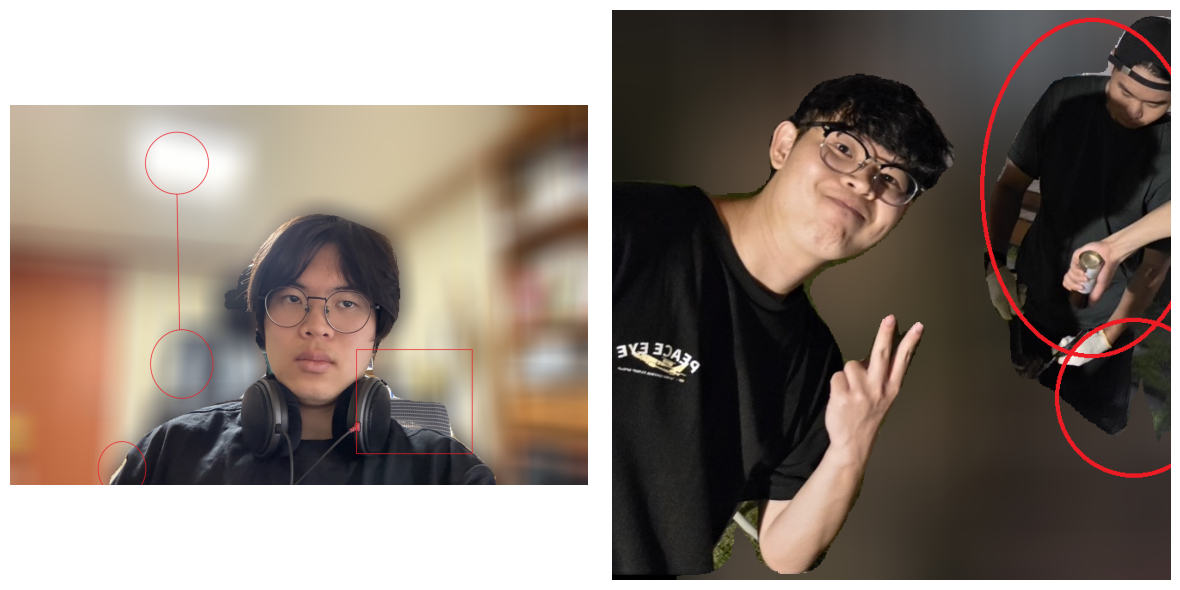

In [15]:

img1 = PILImage.open("outputs/result1a.png")
img2 = PILImage.open("outputs/result2a.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img1)
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 문제점 
1. 경계선의 비슷한 질감이나 색을 가진 테두리가 제대로 식별되지 않으며(왼쪽사진 어깨부분) 이로 인해 경계선이 구불구불함 
2. 모든 영역이 동일한 블러로 처리되어 피사체와 배경의 거리 차이, 초점거리에 따른 광학적 효과인 피사계 심도가 정확하게 구현되지 않음(왼쪽사진 천장과 벽)
3. 그로 인해 오른쪽 사진처럼 피사체를 거리에 따라 배제하지 않고 그저 대상으로 분류된 객체들을 모두 그대로 나타냄(오른쪽 사진)
4. 

## 해결 방안
문제점의 2번에서 말했듯이 semantic segmentation mask 기반으로 만들어본 지금의 '인물 사진'은 인물 모드의 피사계 심도 효과를 그럴듯하게 따라할 뿐 적절히 구현되지 않았다. 

그 이유는 다음과 같은데, 
1. 피사계 심도 효과는 렌즈의 초점거리, 피사체와의 거리, 주변 배경과의 거리로 인해 발생되는 광학 효과이다.
2. 그런데 우리가 이렇게 만든 사진에는 위의 정보 중 어느 것도 들어있거나 물리적으로 구현되어 있지 않다. 
3. 실제 휴대폰 카메라의 인물 모드에서는 이를 보완하기 위해 LiDAR 센서를 통해 depth map을 얻고, 이를 통해 적절히 초점 효과를 조정한다. 

그런데 우리는 현재 인공지능 모델을 통한 소프트웨어적 처리를 다루고 있기 때문에 원리적인 보완은 불가능하며 적절한 대체 방안을 찾아야 하는데, 
그 주된 방향은 아래와 같아야 할 것이다. 
1. 이미지를 기반으로 주 피사체와 배경을 구분해내고,
2. 거리를 추정하여
3. 블러 효과를 구간마다 다르게(초점면에 가까운 영역은 약하게, 멀 수록 강하게) 처리
   

이를 위해서는 semantic segmentation mask를 최종 결과로 그대로 사용하는 것이 아니라, 우선적으로 '어디까지가 사람인가'를 대략적으로 찾아주는 역할을 맡아 초기 방향을 잡아주고 후처리(3)와 보조 모델(2)의 입력으로 활용하는 방식이 적절하다. 

--- 

1. Semantic Segmentation + Instance 분리

Semantic Segmentation은 의미론적 분할이기 때문에 단순히 모든 사람을 동일하게 person 클래스로 처리한다. 실제 인물 모드 구현을 위해서는 사람과 배경을 나누는 것을 넘어, 여러 사람 중 누가 주 피사체인지 판별(Instance segmentation)해야 한다. 

이를 보완하기 위해서는 person mask를 얻은 뒤, 그 안에서 connected component(서로 붙어 있는 픽셀 덩어리를 하나의 객체로 묶는것) 분석이나 instance segmentation을 적용하여 인물 영역을 개별 객체 단위로 분리할 필요가 있다. 이렇게 분리된 각 인물 후보에 대해 다음과 같은 기준을 사용할 수 있다.

 - 화면 중앙에 가까운가(보통 주 피사체를 중앙에 놓으니)
 - 화면에서 차지하는 면적이 큰가
 - 얼굴이 검출되는가
 - 추정된 depth 상 카메라와 가까운가

이 기준들을 조합하면, 단순히 사람 전체가 아니라 이 장면에서 초점이 맞아야 할 주 피사체를 선택할 수 있다.
즉, semantic mask -> 사람 후보 검출-> 후보별 분리 -> 주 피사체 선택의 과정을 거치면 semantic segmentation의 한계였던 모든 person을 동일하게 취급하는 문제를 줄일 수 있다.

2. 거리 정보 예?측
   현재 결과물은 배경 전역에 동일한 blur가 적용되어 있는데, 이 방식은 실제 광학적 보케 효과와는 다르다.
   소프트웨어적으로 보완하려면 monocular depth estimation을 이용할 수 있다. 이는 단일 RGB 이미지 한 장만으로도 각 픽셀의 상대적 거리(depth)를 추정하는 기술이다. 예를 들어 MiDaS, DPT, struct2Depth 계열 모델들은 장면의 구조를 바탕으로 “어떤 영역이 가깝고 먼지”를 추정할 수 있다. 이렇게 추정된 depth map을 바탕으로 기존의 mask에서 검출된 주 피사체 영역의 평균 depth를 구하고, 이를 기준으로 다른 영역들의 depth 차를 구하여 그 차에 비례하는 만큼의 블러 효과를 적용한다면 보다 실감나는 인물 샂진 모드 효과를 만들어볼 수 있을 것이다.

3. 경계선 개선
    머리카락, 어깨, 옷 가장자리, 색이나 재질이 비슷한 부분 근처에서는 경계선이 매우 부자연스러워진다. 이를 극복하기 위해서는 CRF, Guided Filter, Alpha matting 등을 사용해볼 수 있는데 모두 경계선의 부분에서 자연스럽게 값이 달라지게 만드는 방법이다.

---

이 해결 방안을 적용해본 최종 처리 단계는 다음과 같다. 

이미지 입력
   ↓
DeepLab semantic segmentation
   ↓
person mask 생성
   ↓
instance 분리 / 주 피사체 선택
   ↓
monocular depth estimation -> 주 피사체 depth 기준으로 나머지 영역 depth 계산 
   ↓
3.번 방법들으로 mask 경계 보정
   ↓
depth 기반 blur 적용
   ↓
alpha blending으로 원본과 합성
   ↓
최종 인물 모드 이미지
    



원본 고양이 이미지 크기: (1592, 1206, 3)
배경(사막) 이미지 크기: (225, 225, 3)


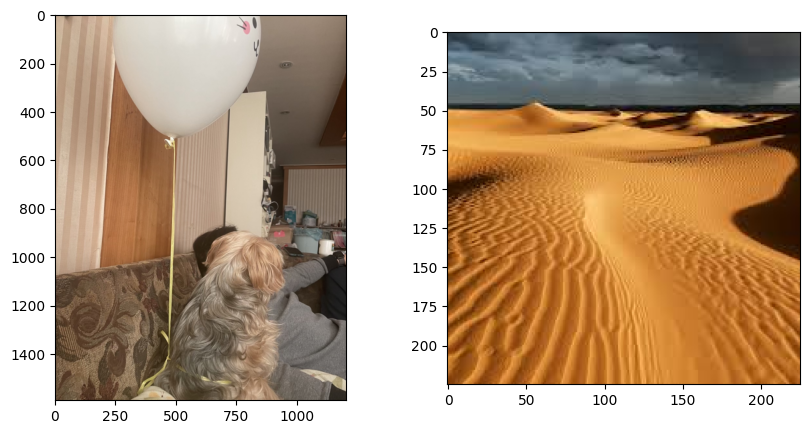

In [16]:
dog_img_path = "images/dog.jpg"  # 고양이 이미지를 준비해주세요
sand_img_path = "images/sand.jpg"  # 사막 배경 이미지를 준비해주세요

dog_img = cv2.imread(dog_img_path)
sand_img = cv2.imread(sand_img_path)

dog_img = cv2.cvtColor(dog_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {dog_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(dog_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

In [17]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(dog_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [18]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (dog_img.shape[1], dog_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (1592, 1206)


In [19]:
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]

unique_classes = np.unique(output_predictions_resized)
unique_labels = [LABEL_NAMES[class_id] for class_id in unique_classes]

print(f"예측된 클래스 ID: {tuple(unique_classes)}")
print(f"예측된 클래스 Label: {tuple(unique_labels)}")

예측된 클래스 ID: (0, 12, 18)
예측된 클래스 Label: ('background', 'dog', 'sofa')


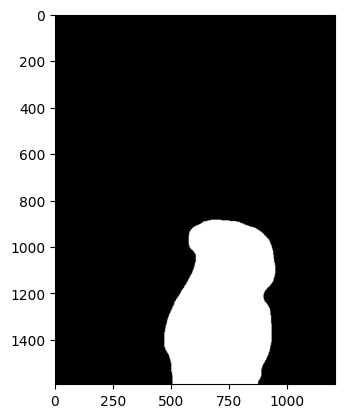

In [20]:
target_class_id = 12 # 기존 리스트 방식 쓰면 객체 여러개일때 오류나서 그냥 id로 하드코딩..그냥 얌전히 예시 쓸걸..

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

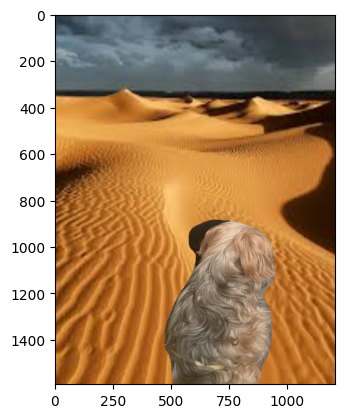

In [21]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (dog_img.shape[1], dog_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, dog_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()